In [8]:
from keeper import Keeper
from influxdb_client import InfluxDBClient
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

k = Keeper(config_path="C:/Users/ThijsAntoniedeBoer/OneDrive - HELION/Dokumente/python-projects/Repositories/keeper/keeper/keeper_config.json")

token = k.get_password("Auroras Token")



,time,soc
2875,2026-03-01 23:57:30+00:00,79.003583
2876,2026-03-01 23:58:00+00:00,78.984064
2877,2026-03-01 23:58:30+00:00,78.964585
2878,2026-03-01 23:59:00+00:00,78.831456
2879,2026-03-01 23:59:30+00:00,78.815519


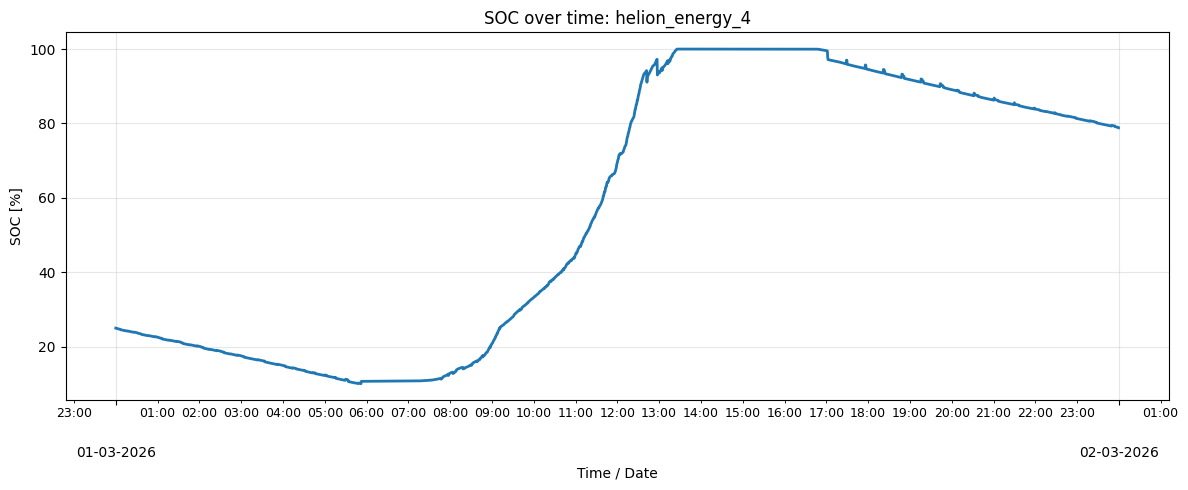

In [88]:
org = "helionenergy"
url = "https://influxdb-helionenergy.aurorasgrid.com"
bucket = "ems_data"
target_measurement = "helion_energy_4"
field_name = "vb_internal_soc"
start_time = "2026-03-01T00:00:00Z"
stop_time = "2026-03-02T00:00:00Z"

query = f'''
from(bucket: "{bucket}")
  |> range(start: {start_time}, stop: {stop_time})
  |> filter(fn: (r) => r["_measurement"] == "{target_measurement}")
  |> filter(fn: (r) => r["_field"] == "{field_name}")
  |> sort(columns: ["_time"])
'''
records = []

with InfluxDBClient(url=url, token=token, org=org) as client:
    tables = client.query_api().query(query)

    for table in tables:
        for record in table.records:
            records.append(
                {
                    "time": record.get_time(),
                    "soc": record.get_value(),
                }
            )

soc_df = pd.DataFrame(records)

if soc_df.empty:
    print("No SOC data returned for the selected measurement and time range.")
else:
    soc_df["time"] = pd.to_datetime(soc_df["time"])
    soc_df = soc_df.sort_values("time")

    display(soc_df.tail())

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(soc_df["time"], soc_df["soc"], linewidth=2)
    ax.set_title(f"SOC over time: {target_measurement}")
    ax.set_xlabel("Time / Date")
    ax.set_ylabel("SOC [%]")
    ax.grid(True, alpha=0.3)

    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter("%H:%M"))
    ax.tick_params(axis="x", which="minor", labelsize=9, pad=3)

    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("\n%d-%m-%Y"))
    ax.tick_params(axis="x", which="major", labelsize=10, pad=18)

    plt.tight_layout()
    plt.show()